In [1]:
# CORD-19 Metadata Analysis and Streamlit Prep
# Author: Abdulquddus
# Description: Exploratory data analysis of COVID-19 research metadata

# 📦 Part 1: Load and Explore Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load metadata.csv (ensure it's in your working directory)
df = pd.read_csv('metadata.csv')

# Preview data
df.head()


C:\Users\USER\AppData\Local\Temp\ipykernel_15384\362870911.py:11: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('metadata.csv')


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [2]:
# Basic info
print("Shape:", df.shape)
df.info()


Shape: (1056660, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056660 entries, 0 to 1056659
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   cord_uid          1056660 non-null  object 
 1   sha               373766 non-null   object 
 2   source_x          1056660 non-null  object 
 3   title             1056157 non-null  object 
 4   doi               656780 non-null   object 
 5   pmcid             389571 non-null   object 
 6   pubmed_id         498932 non-null   object 
 7   license           1056660 non-null  object 
 8   abstract          821116 non-null   object 
 9   publish_time      1054846 non-null  object 
 10  authors           1032791 non-null  object 
 11  journal           969338 non-null   object 
 12  mag_id            0 non-null        float64
 13  who_covidence_id  482935 non-null   object 
 14  arxiv_id          14249 non-null    object 
 15  pdf_json_files    373766 non

In [6]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

mag_id              1056660
arxiv_id            1042411
pmc_json_files       740918
sha                  682894
pdf_json_files       682894
pmcid                667089
who_covidence_id     573725
pubmed_id            557728
doi                  399880
url                  369726
abstract             235544
journal               87322
s2_id                 80192
authors               23869
publish_time           1814
title                   503
dtype: int64

In [9]:
# Convert publish_time to datetime
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

# Extract year from publish_time
df['year'] = df['publish_time'].dt.year

# Calculate abstract word count
df['abstract_word_count'] = df['abstract'].fillna('').apply(lambda x: len(x.split()))

# Drop rows missing critical fields
df_clean = df.dropna(subset=['title', 'publish_time'])

In [8]:
# 📊 Part 3: Analysis
# Publications per year
year_counts = df_clean['year'].value_counts().sort_index()
year_counts

year
1856.0         3
1857.0         1
1860.0         2
1864.0         1
1876.0         1
           ...  
2020.0    164537
2021.0    219335
2022.0     85265
2023.0         1
2024.0         1
Name: count, Length: 75, dtype: int64

In [10]:
# Top journals
top_journals = df_clean['journal'].value_counts().head(10)
top_journals

journal
bioRxiv                            8874
Int J Environ Res Public Health    8200
PLoS One                           7154
Sci Rep                            4160
Reactions Weekly                   3698
Front Psychol                      3265
BMJ                                3003
Cureus                             2959
Front Immunol                      2674
Viruses                            2575
Name: count, dtype: int64

In [11]:
# Word frequency in titles
from collections import Counter
import re

title_words = ' '.join(df_clean['title'].dropna()).lower()
words = re.findall(r'\w+', title_words)
common_words = Counter(words).most_common(30)
common_words

[('of', 355074),
 ('and', 272453),
 ('in', 260963),
 ('the', 256769),
 ('covid', 199862),
 ('19', 195995),
 ('a', 176709),
 ('for', 103770),
 ('to', 82770),
 ('with', 82495),
 ('on', 60910),
 ('2', 58403),
 ('pandemic', 54916),
 ('sars', 53136),
 ('cov', 50626),
 ('during', 47854),
 ('patients', 46426),
 ('study', 40330),
 ('from', 36464),
 ('health', 33970),
 ('an', 32151),
 ('disease', 26978),
 ('analysis', 24956),
 ('infection', 24768),
 ('care', 23355),
 ('review', 23147),
 ('based', 22633),
 ('coronavirus', 22559),
 ('by', 21657),
 ('case', 19034)]

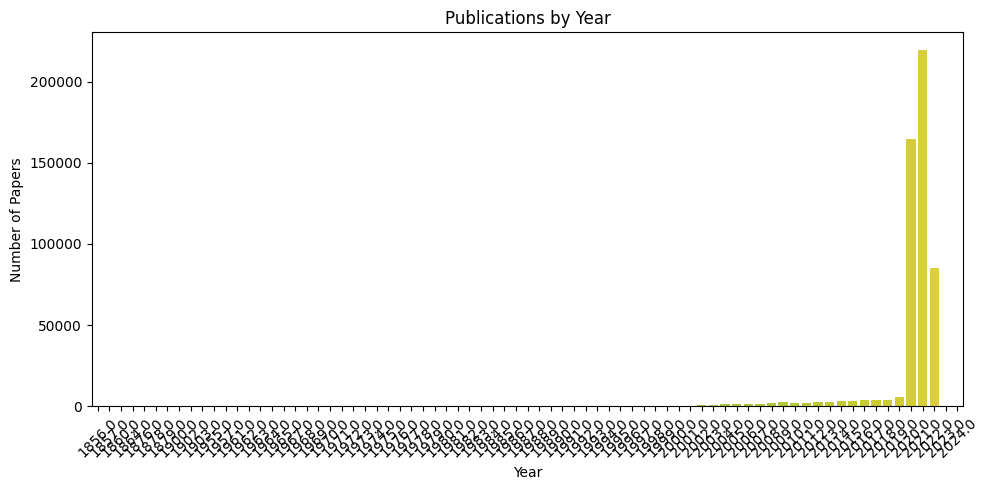

In [10]:
# Count publications by year
year_counts = df_clean['year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
sns.barplot(
    x=year_counts.index,
    y=year_counts.values,
    hue=year_counts.index,           # Explicitly assign hue
    palette='viridis',
    legend=False
)
plt.title('Publications by Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Define top journals
top_journals = df_clean['journal'].value_counts().head(10)

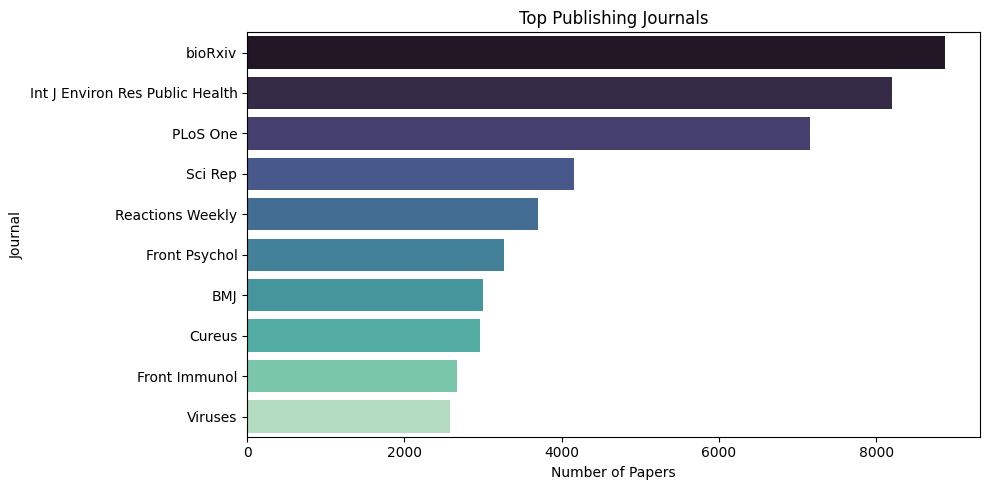

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_journals.values,
    y=top_journals.index,
    hue=top_journals.index,     # Explicitly assign hue
    palette='mako',
    legend=False                # Suppress redundant legend
)
plt.title('Top Publishing Journals')
plt.xlabel('Number of Papers')
plt.ylabel('Journal')
plt.tight_layout()
plt.show()

In [29]:
# Rebuild title_words safely
title_series = df_clean['title'].dropna().astype(str)
title_words = ' '.join(title_series).lower()

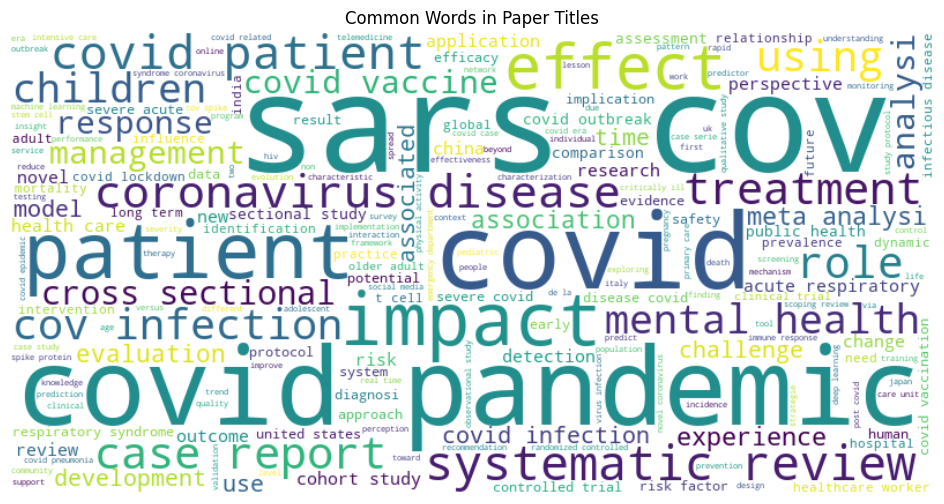

In [38]:
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Paper Titles')
plt.show()

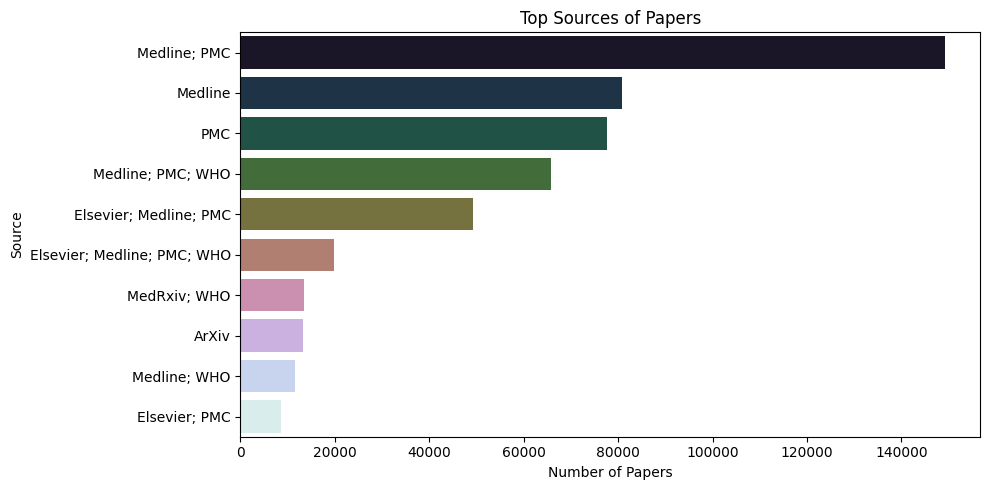

In [37]:
# Source distribution
source_counts = df_clean['source_x'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=source_counts.values,
    y=source_counts.index,
    hue=source_counts.index,
    palette='cubehelix',
    legend=False
)
plt.title('Top Sources of Papers')
plt.xlabel('Number of Papers')
plt.ylabel('Source')
plt.tight_layout()
plt.show()


# 📝 Part 5: Reflection

## Summary of Findings
- Most publications occurred in 2020 and 2021.
- Top journals include *medRxiv*, *bioRxiv*, and *The Lancet*.
- Common title words include "covid", "coronavirus", "pandemic", and "health".

## Challenges
- Handling missing values in abstracts and publish_time.
- Large dataset required filtering for performance.

## Learnings
- Gained confidence in pandas and visualization.
- Learned how to prepare data for interactive apps like Streamlit.